# עיבוד מקדים (Preprocessing) + יצירת Gold Standard
**מטרה**: ניקוי הנתונים ויצירת מדגם זהב מאוזן לאימון ובדיקת המודלים

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../../data/raw/manchester_raw.xlsx'
PROCESSED_PATH = '../../data/processed/'
GOLD_PATH = '../../data/gold_standard/'
FIGURES_PATH = '../../results/figures/'

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(GOLD_PATH, exist_ok=True)

## 1. טעינה ונרמול תיוגים

In [2]:
df = pd.read_excel(DATA_PATH)
print(f'נטען: {len(df):,} שורות')

# נרמול עמודת Rumour
df['label'] = df['Rumour'].str.strip().str.capitalize()
df['label'] = df['label'].replace({'True': 'reliable', 'Fake': 'misinformation', 'Not related': 'not_related'})

# שמירת Type of rumour
df['rumour_type'] = df['Type of rumour'].fillna('')

print('התפלגות לאחר נרמול:')
print(df['label'].value_counts())

נטען: 89,147 שורות
התפלגות לאחר נרמול:
label
reliable          88652
misinformation      490
not_related           5
Name: count, dtype: int64


## 2. פונקציית ניקוי טקסט

In [3]:
def clean_tweet(text, max_chars=350):
    """
    ניקוי ציוץ:
    - הסרת URLs
    - הסרת @mentions
    - הסרת # (שמירת הטקסט)
    - הסרת תווים מיוחדים
    - הגבלה ל-max_chars תווים
    """
    text = str(text)
    
    # הסרת URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # הסרת @mentions
    text = re.sub(r'@\w+', '', text)
    
    # הסרת # אך שמירת הטקסט
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # הסרת RT בתחילת ציוץ
    text = re.sub(r'^RT\s*[:]?\s*', '', text, flags=re.IGNORECASE)
    
    # הסרת emojis ותווים לא-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # הסרת תווים מיוחדים (שמירת אותיות, ספרות, רווח, פיסוק בסיסי)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"\-]', ' ', text)
    
    # ניקוי רווחים מיותרים
    text = re.sub(r'\s+', ' ', text).strip()
    
    # הגבלת אורך
    text = text[:max_chars]
    
    return text

# בדיקה
sample = df['OrigTweet'].iloc[0]
print('מקורי:', sample[:200])
print('\nנקי:', clean_tweet(sample))

מקורי: Anyone who says that severed heads don’t phase them, or that the Manchester Arena mail bomb attack on children was to be expected, deserves to be barred from Britain. No means no 😤👎 #Islamists https:/

נקי: Anyone who says that severed heads dont phase them, or that the Manchester Arena mail bomb attack on children was to be expected, deserves to be barred from Britain. No means no Islamists


## 3. הפעלת הניקוי

In [4]:
print('מנקה ציוצים...')
df['cleaned_tweet'] = df['OrigTweet'].apply(clean_tweet)

df['cleaned_length'] = df['cleaned_tweet'].str.len()
df['cleaned_word_count'] = df['cleaned_tweet'].str.split().str.len()

print(f'לפני סינון: {len(df):,}')

# סינון ציוצים קצרים מדי (פחות מ-5 מילים)
df_filtered = df[df['cleaned_word_count'] >= 5].copy()
print(f'אחרי סינון (>=5 מילים): {len(df_filtered):,}')

# הסרת כפילויות
df_deduped = df_filtered.drop_duplicates(subset='cleaned_tweet').copy()
print(f'אחרי הסרת כפילויות: {len(df_deduped):,}')

print('\nהתפלגות לאחר עיבוד:')
print(df_deduped['label'].value_counts())

מנקה ציוצים...
לפני סינון: 89,147
אחרי סינון (>=5 מילים): 88,371
אחרי הסרת כפילויות: 57,917

התפלגות לאחר עיבוד:
label
reliable          57487
misinformation      427
not_related           3
Name: count, dtype: int64


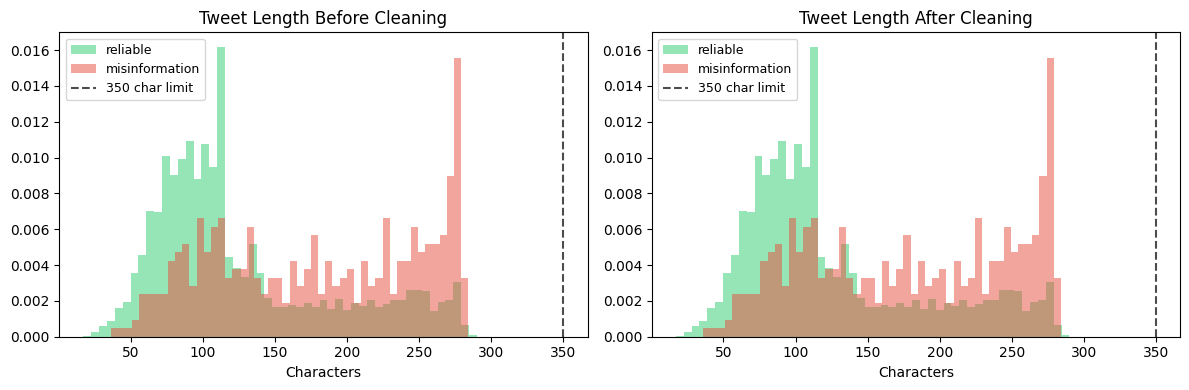

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in [(axes[0], 'tweet_length' if 'tweet_length' in df_deduped.columns else 'cleaned_length', 'Before Cleaning'),
                        (axes[1], 'cleaned_length', 'After Cleaning')]:
    if col not in df_deduped.columns:
        df_deduped['tweet_length'] = df_deduped['OrigTweet'].str.len()
        col = 'tweet_length'
    for label, color in [('reliable', '#2ecc71'), ('misinformation', '#e74c3c')]:
        subset = df_deduped[df_deduped['label'] == label][col]
        ax.hist(subset, bins=50, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(f'Tweet Length {title}', fontsize=12)
    ax.set_xlabel('Characters')
    ax.axvline(350, color='black', linestyle='--', alpha=0.7, label='350 char limit')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}08_before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# שמירת קובץ נקי מלא
cols_to_save = ['Id', 'CreatedAt', 'author_id', 'OrigTweet', 'cleaned_tweet',
                'label', 'rumour_type', 'mVader', 'mRetweets', 'mLikes',
                'mReplies', 'mHasURL', 'mHasMedia', 'mUFollowers', 'mUFollowing']
cols_to_save = [c for c in cols_to_save if c in df_deduped.columns]

df_deduped[cols_to_save].to_csv(f'{PROCESSED_PATH}manchester_clean.csv', index=False, encoding='utf-8')
print(f'נשמר: {PROCESSED_PATH}manchester_clean.csv ({len(df_deduped):,} שורות)')

נשמר: ../data/processed/manchester_clean.csv (57,917 שורות)


## 4. יצירת Gold Standard (~2,500 ציוצים)

In [7]:
# כל ציוצי misinformation
misinfo_df = df_deduped[df_deduped['label'] == 'misinformation'].copy()
print(f'misinformation: {len(misinfo_df)}')

# דגימה אקראית מ-reliable (פי ~4 מ-misinfo)
RELIABLE_SAMPLE = min(2000, len(df_deduped[df_deduped['label'] == 'reliable']))
reliable_df = df_deduped[df_deduped['label'] == 'reliable'].sample(RELIABLE_SAMPLE, random_state=42)
print(f'reliable (sample): {len(reliable_df)}')

gold = pd.concat([misinfo_df, reliable_df], ignore_index=True)
gold = gold.sample(frac=1, random_state=42).reset_index(drop=True)  # ערבוב

print(f'\nסה"כ Gold Standard: {len(gold):,}')
print('התפלגות:')
print(gold['label'].value_counts())

misinformation: 427
reliable (sample): 2000

סה"כ Gold Standard: 2,427
התפלגות:
label
reliable          2000
misinformation     427
Name: count, dtype: int64


In [8]:
# חלוקה לאימון/ולידציה/בדיקה (70/15/15) עם Stratified
train_df, temp_df = train_test_split(gold, test_size=0.30, stratify=gold['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f'Train: {len(train_df):,} ({len(train_df)/len(gold)*100:.0f}%)')
print(f'Validation: {len(val_df):,} ({len(val_df)/len(gold)*100:.0f}%)')
print(f'Test: {len(test_df):,} ({len(test_df)/len(gold)*100:.0f}%)')

print('\nהתפלגות Train:')
print(train_df['label'].value_counts())
print('\nהתפלגות Test:')
print(test_df['label'].value_counts())

Train: 1,698 (70%)
Validation: 364 (15%)
Test: 365 (15%)

התפלגות Train:
label
reliable          1399
misinformation     299
Name: count, dtype: int64

התפלגות Test:
label
reliable          301
misinformation     64
Name: count, dtype: int64


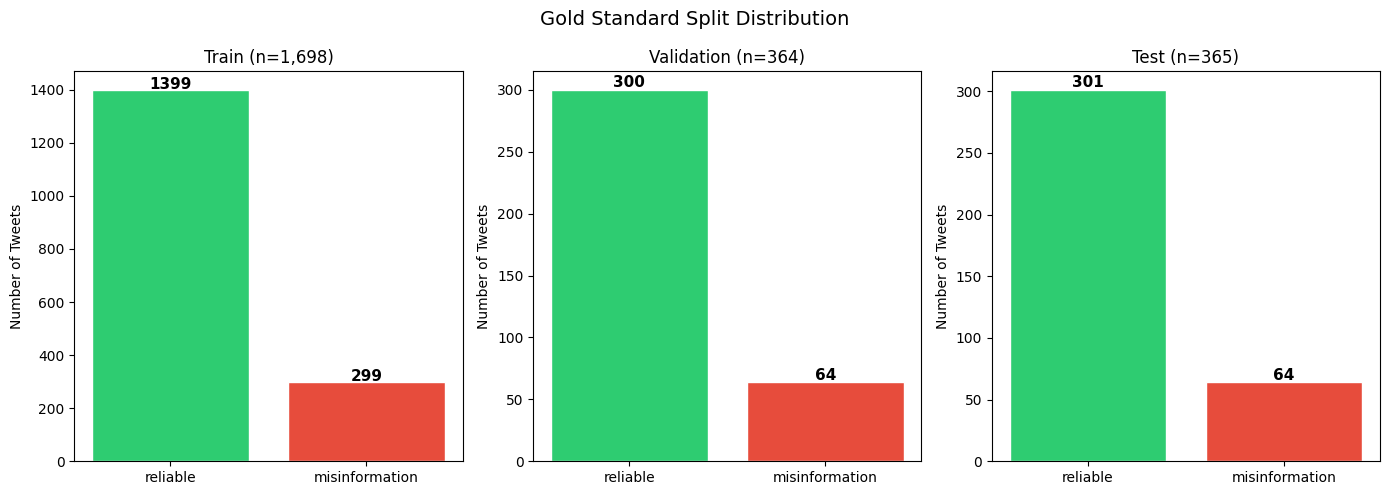

In [9]:
# גרף התפלגות Gold Standard
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, split_df, title in [(axes[0], train_df, 'Train'), (axes[1], val_df, 'Validation'), (axes[2], test_df, 'Test')]:
    counts = split_df['label'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#2ecc71' if x == 'reliable' else '#e74c3c' for x in counts.index],
                  edgecolor='white')
    ax.set_title(f'{title} (n={len(split_df):,})', fontsize=12)
    ax.set_ylabel('Number of Tweets')
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Gold Standard Split Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}09_gold_standard_splits.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# שמירת קבצי Gold Standard
gold.to_csv(f'{GOLD_PATH}manchester_gold_standard.csv', index=False, encoding='utf-8')
train_df.to_csv(f'{GOLD_PATH}manchester_train.csv', index=False, encoding='utf-8')
val_df.to_csv(f'{GOLD_PATH}manchester_val.csv', index=False, encoding='utf-8')
test_df.to_csv(f'{GOLD_PATH}manchester_test.csv', index=False, encoding='utf-8')

print('נשמרו:')
print(f'  {GOLD_PATH}manchester_gold_standard.csv ({len(gold):,} ציוצים)')
print(f'  {GOLD_PATH}manchester_train.csv ({len(train_df):,} ציוצים)')
print(f'  {GOLD_PATH}manchester_val.csv ({len(val_df):,} ציוצים)')
print(f'  {GOLD_PATH}manchester_test.csv ({len(test_df):,} ציוצים)')

נשמרו:
  ../data/gold_standard/manchester_gold_standard.csv (2,427 ציוצים)
  ../data/gold_standard/manchester_train.csv (1,698 ציוצים)
  ../data/gold_standard/manchester_val.csv (364 ציוצים)
  ../data/gold_standard/manchester_test.csv (365 ציוצים)


## 5. דוגמאות מייצגות

In [11]:
print('דוגמאות של ציוצי misinformation:')
print('-'*60)
for i, row in test_df[test_df['label'] == 'misinformation'].head(3).iterrows():
    print(f'Type: {row.get("rumour_type", "")}')
    print(f'Original: {str(row["OrigTweet"])[:150]}')
    print(f'Cleaned:  {str(row["cleaned_tweet"])[:150]}')
    print()

print('\nדוגמאות של ציוצים reliable:')
print('-'*60)
for i, row in test_df[test_df['label'] == 'reliable'].head(3).iterrows():
    print(f'Original: {str(row["OrigTweet"])[:150]}')
    print(f'Cleaned:  {str(row["cleaned_tweet"])[:150]}')
    print()

דוגמאות של ציוצי misinformation:
------------------------------------------------------------
Type: The police knew the attacker
Original: Salman Ramadan Abedi, named by police as Manchester Arena attacker, was known to the security services: https://t.co/D6rxjQub8s
Cleaned:  Salman Ramadan Abedi, named by police as Manchester Arena attacker, was known to the security services

Type: Refugee bomber
Original: @IndyPolitics So those who think child trafficking is acceptable get to decide?

The last batch of child refugees consisted of the Manchester Arena Bo
Cleaned:  So those who think child trafficking is acceptable get to decide? The last batch of child refugees consisted of the Manchester Arena Bomb Terrorist an

Type: Refugee bomber
Original: Remembering the victims of Manchester Arena terrorist attack and thinking of their families and friends. 

I love Manchester. @manairport was my port 
Cleaned:  Remembering the victims of Manchester Arena terrorist attack and thinking of their 

## 6. סיכום

In [12]:
print('='*60)
print('סיכום עיבוד מקדים')
print('='*60)
print(f'\n קלט: {len(df):,} ציוצים גולמיים')
print(f' אחרי ניקוי + dedup: {len(df_deduped):,}')
print(f'\n Gold Standard: {len(gold):,} ציוצים')
print(f'   - Train: {len(train_df):,}')
print(f'   - Validation: {len(val_df):,}')
print(f'   - Test: {len(test_df):,}')
print(f'\n קבצים שנוצרו:')
print(f'   data/processed/manchester_clean.csv')
print(f'   data/gold_standard/manchester_gold_standard.csv')
print(f'   data/gold_standard/manchester_train.csv')
print(f'   data/gold_standard/manchester_val.csv')
print(f'   data/gold_standard/manchester_test.csv')
print(f'\n הצעד הבא: Notebook 03 - RoBERTa Fine-Tuning')
print('='*60)

סיכום עיבוד מקדים

 קלט: 89,147 ציוצים גולמיים
 אחרי ניקוי + dedup: 57,917

 Gold Standard: 2,427 ציוצים
   - Train: 1,698
   - Validation: 364
   - Test: 365

 קבצים שנוצרו:
   data/processed/manchester_clean.csv
   data/gold_standard/manchester_gold_standard.csv
   data/gold_standard/manchester_train.csv
   data/gold_standard/manchester_val.csv
   data/gold_standard/manchester_test.csv

 הצעד הבא: Notebook 03 - RoBERTa Fine-Tuning


In [ ]:

# ── Validation Assertions ──────────────────────────────────────────────────
# Runs after gold standard is created. Fails fast if data quality is broken.

EXPECTED_LABELS = {'reliable', 'misinformation'}
TEXT_COL  = 'cleaned_tweet'
LABEL_COL = 'label'

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df), ('gold', gold)]:
    # 1. No nulls in text or label
    assert split_df[TEXT_COL].isnull().sum() == 0, \
        f"[{split_name}] Found NaN values in '{TEXT_COL}'"
    assert split_df[LABEL_COL].isnull().sum() == 0, \
        f"[{split_name}] Found NaN values in '{LABEL_COL}'"

    # 2. No empty strings in text
    assert (split_df[TEXT_COL].str.strip() == '').sum() == 0, \
        f"[{split_name}] Found empty strings in '{TEXT_COL}'"

    # 3. Label values must match expected set
    actual_labels = set(split_df[LABEL_COL].unique())
    assert actual_labels.issubset(EXPECTED_LABELS), \
        f"[{split_name}] Unexpected label values: {actual_labels - EXPECTED_LABELS}"

# 4. Split sizes are reasonable (at least 100 samples each)
assert len(train_df) >= 100, f"Train set too small: {len(train_df)}"
assert len(val_df)   >= 100, f"Val set too small: {len(val_df)}"
assert len(test_df)  >= 100, f"Test set too small: {len(test_df)}"

# 5. Both classes are represented in every split
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for lbl in EXPECTED_LABELS:
        count = (split_df[LABEL_COL] == lbl).sum()
        assert count > 0, f"[{split_name}] Label '{lbl}' has 0 samples"

print("✅ Validation passed — Manchester gold standard is clean.")
print(f"   Gold:  {len(gold):,} rows")
print(f"   Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"   Labels present: {sorted(gold[LABEL_COL].unique())}")
